In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, conv=GCNConv):
        super(Encoder, self).__init__()
        self.conv1 = conv(dim_in, hidden_channels)
        self.conv_mu = conv(hidden_channels, dim_out)
        self.conv_logstd = conv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd

In [6]:
from torch import load
modeles_dim   =   load("../resultats/modeles_dim.pth",weights_only=False)

In [7]:
from torch import load

train_data = load('../data/train_data.pt',weights_only=False)
val_data = load('../data/val_data.pt',weights_only=False)
test_data = load('../data/test_data.pt',weights_only=False)

data = load('../data/data.pt',weights_only=False)

# chargement des modèles

modeles_convs = load("../resultats/modeles_convs.pth",weights_only=False)

# chargement des historiques

resultats_dim = load("../resultats/resultats_dim.pth",weights_only=False)
resultats_convs = load("../resultats/resultats_convs.pth",weights_only=False)



In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

# Reconstruction du tableau depuis les résultats sauvegardés.
df_dimensions = pd.DataFrame(resultats_dim)

# Baseline : une paire d'aéroports proche géographiquement reçoit un score élevé.
aretes_test = th.cat([
    test_data.pos_edge_label_index,
    test_data.neg_edge_label_index,
], dim=1).cpu().numpy()
labels_test = np.concatenate([
    np.ones(test_data.pos_edge_label_index.size(1)),
    np.zeros(test_data.neg_edge_label_index.size(1)),
])
coordonnees = data.x[:, :2].cpu().numpy()
lat1 = np.radians(coordonnees[aretes_test[0], 1])
lon1 = np.radians(coordonnees[aretes_test[0], 0])
lat2 = np.radians(coordonnees[aretes_test[1], 1])
lon2 = np.radians(coordonnees[aretes_test[1], 0])
a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
distances_test = 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
scores_distance = -distances_test
baseline = {
    "AUC": roc_auc_score(labels_test, scores_distance),
    "AP": average_precision_score(labels_test, scores_distance),
}
print(f"Baseline distance : AUC = {baseline['AUC']:.4f} - AP = {baseline['AP']:.4f}")

Baseline distance : AUC = 0.9096 - AP = 0.9196


In [8]:
def resumer(df, colonnes):
    # moyenne et écart-type sur les seeds
    return df.groupby(colonnes, sort=False)[["AUC", "AP"]].agg(["mean", "std"]).round(4)


def tracer_barres(df, col_groupe, col_serie=None, titre="", ylim=(0.4, 1.03)):
    # barres AUC / AP (moyenne ± écart-type sur les seeds) + ligne de la baseline distance (section 1)
    if col_serie is None:
        df = df.assign(_serie="VGAE")
        col_serie = "_serie"
    stats = df.groupby([col_groupe, col_serie], sort=False)[["AUC", "AP"]].agg(["mean", "std"])
    groupes = list(dict.fromkeys(df[col_groupe]))
    series = list(dict.fromkeys(df[col_serie]))
    largeur = 0.8 / len(series)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metrique in zip(axes, ["AUC", "AP"]):
        for i, serie in enumerate(series):
            positions = [g + (i - (len(series) - 1) / 2) * largeur for g in range(len(groupes))]
            moyennes = [stats.loc[(g, serie), (metrique, "mean")] for g in groupes]
            ecarts = [stats.loc[(g, serie), (metrique, "std")] for g in groupes]
            barres = ax.bar(positions, moyennes, largeur, yerr=ecarts, capsize=3,
                            label=serie if col_serie != "_serie" else None)
            ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=7)
        ax.axhline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1, label="baseline distance")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="hasard")
        ax.set_xticks(range(len(groupes)), groupes)
        ax.set_ylim(*ylim)
        ax.set_title(f"{metrique} test — {titre}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def tracer_loss(historiques, titre):
    # courbes de loss train (trait plein) et validation (pointillés), échelle log
    plt.figure(figsize=(8, 4))
    for nom, history in historiques.items():
        ligne, = plt.plot(history["train"], label=f"{nom} train")
        plt.plot(history["val"], linestyle="--", color=ligne.get_color(), label=f"{nom} val")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (échelle log)")
    plt.title(titre)
    plt.legend(fontsize=8)
    plt.show()


def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    with th.no_grad():
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Récupération de toutes les arêtes positives et négatives
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf = lemodele.test(z, pos_edges, neg_edges)
        predictions = (probabilites >= 0.5).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[0]:.4f} (vrai_positif/faux_positif) - AP {perf[1]:.4f} ( précision/rappel )")

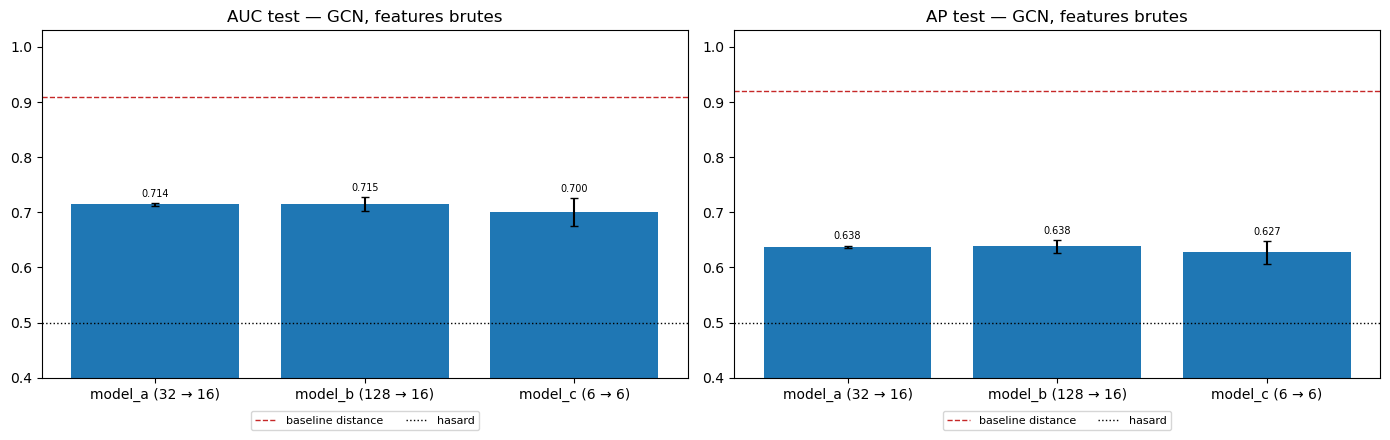

Historiques de loss non sauvegardés : graphique ignoré.

Matrice de confusion — model_a (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1195 1514]
 [  64 2645]]
Perf : AUC 0.7120 (vrai_positif/faux_positif) - AP 0.6357 ( précision/rappel )

Matrice de confusion — model_b (128 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1100 1609]
 [  40 2669]]
Perf : AUC 0.7001 (vrai_positif/faux_positif) - AP 0.6257 ( précision/rappel )

Matrice de confusion — model_c (6 → 6) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1247 1462]
 [ 108 2601]]
Perf : AUC 0.7155 (vrai_positif/faux_positif) - AP 0.6394 ( précision/rappel )


In [11]:
tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
if "historiques_dim" in globals():
    tracer_loss(historiques_dim, "Courbes de loss (seed 0)")
else:
    print("Historiques de loss non sauvegardés : graphique ignoré.")
for nom, model in modeles_dim.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")